In [9]:
import torch
import torch.nn as nn
import numpy as np
import polars as pl
import glob
import os

from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score

In [10]:
# DEVICE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [12]:
# LOAD CHUNKS (MANUAL FIXED SPLIT)
def get_chunk_number(path):
    return int(path.split("_")[-1].replace(".parquet", ""))

all_chunks = sorted(
    glob.glob("DataSet/6_class_chunks/*.parquet"),
    key=get_chunk_number
)

print("Total chunks found:", len(all_chunks))

# ---- SAFETY CHECK ----
assert len(all_chunks) >= 164, \
    f"Expected at least 164 chunks, found {len(all_chunks)}"

# ---- FIXED SPLIT ----
train_files = all_chunks[0:148]
test_files  = all_chunks[148:156]
val_files   = all_chunks[156:164]

print("Train:", len(train_files))
print("Test :", len(test_files))
print("Val  :", len(val_files))


Total chunks found: 164
Train: 148
Test : 8
Val  : 8


In [13]:
# LABEL REMAP (1–6 → 0–5)
label_map = {1:0, 2:1, 3:2, 4:3, 5:4, 6:5}

def remap_labels(arr):
    return np.vectorize(label_map.get)(arr)


In [14]:
# CLASS DISTRIBUTION (FOR WEIGHTS)
print("\nCalculating class distribution...")

counts = {}
total = 0

for file in train_files:
    df = pl.read_parquet(file, columns=["Attack"])
    for val in df["Attack"]:
        counts[val] = counts.get(val, 0) + 1
        total += 1

print("Class counts:", counts)

weights = []
for original in sorted(label_map.keys()):
    weights.append(total / counts[original])

weights = torch.tensor(weights, dtype=torch.float32).to(device)
weights = weights / weights.mean()

print("Class weights:", weights)


Calculating class distribution...
Class counts: {1: 19623107, 5: 3412711, 2: 16129971, 4: 104635, 3: 129238, 6: 50004}
Class weights: tensor([0.0081, 0.0099, 1.2315, 1.5211, 0.0466, 3.1828], device='cuda:0')


In [15]:
# MODEL
class ResidualMLP(nn.Module):
    def __init__(self, input_dim=37, num_classes=6):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, 768)
        self.bn1 = nn.BatchNorm1d(768)
        self.drop1 = nn.Dropout(0.25)

        self.fc2 = nn.Linear(768, 768)
        self.bn2 = nn.BatchNorm1d(768)
        self.drop2 = nn.Dropout(0.25)

        self.fc3 = nn.Linear(768, 512)
        self.bn3 = nn.BatchNorm1d(512)

        self.fc4 = nn.Linear(512, 256)
        self.bn4 = nn.BatchNorm1d(256)

        self.fc5 = nn.Linear(256, 128)
        self.bn5 = nn.BatchNorm1d(128)

        self.out = nn.Linear(128, num_classes)

        self.act = nn.GELU()

    def forward(self, x):

        x1 = self.act(self.bn1(self.fc1(x)))
        x1 = self.drop1(x1)

        x2 = self.act(self.bn2(self.fc2(x1)))
        x2 = x2 + x1
        x2 = self.drop2(x2)

        x3 = self.act(self.bn3(self.fc3(x2)))
        x4 = self.act(self.bn4(self.fc4(x3)))
        x5 = self.act(self.bn5(self.fc5(x4)))

        return self.out(x5)

model = ResidualMLP().to(device)


In [16]:
# LOSS / OPTIMIZER / SCHEDULER
# =====================================================
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)

EPOCHS = 12

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS
)

scaler = torch.amp.GradScaler("cuda")

In [17]:
# TRAIN FUNCTION
def train_one_epoch(files):

    model.train()
    total_loss = 0
    total_samples = 0

    for file in files:

        df = pl.read_parquet(file)

        X = df.drop("Attack").to_numpy().astype(np.float32)
        y = remap_labels(df["Attack"].to_numpy().astype(np.int64))

        dataset = TensorDataset(
            torch.from_numpy(X),
            torch.from_numpy(y)
        )

        loader = DataLoader(
            dataset,
            batch_size=8192,
            shuffle=True,
            num_workers=0,
            pin_memory=True
        )

        for xb, yb in loader:

            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            with torch.amp.autocast("cuda"):
                outputs = model(xb)
                loss = criterion(outputs, yb)

            scaler.scale(loss).backward()

            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item() * xb.size(0)
            total_samples += xb.size(0)

        del df, dataset, loader
        torch.cuda.empty_cache()

    return total_loss / total_samples

In [18]:
# EVALUATION
def evaluate(files):

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for file in files:

            df = pl.read_parquet(file)

            X = df.drop("Attack").to_numpy().astype(np.float32)
            y = remap_labels(df["Attack"].to_numpy().astype(np.int64))

            X_tensor = torch.from_numpy(X).to(device)

            outputs = model(X_tensor)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(y)

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return acc, macro_f1

In [ ]:
# TRAIN LOOP
os.makedirs("Trained", exist_ok=True)

best_f1 = 0
patience = 3
no_improve = 0

for epoch in range(EPOCHS):

    print(f"\n===== Epoch {epoch+1}/{EPOCHS} =====")

    train_loss = train_one_epoch(train_files)
    print(f"Train Loss: {train_loss:.6f}")

    val_acc, val_f1 = evaluate(val_files)
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Validation Macro F1: {val_f1:.4f}")

    scheduler.step()

    if val_f1 > best_f1:
        best_f1 = val_f1
        no_improve = 0

        save_path = f"Trained/IDS-MLP-6class-epoch{epoch+1}-F1_{val_f1:.4f}.pth"
        torch.save(model.state_dict(), save_path)

        print("✅ Best model saved")

    else:
        no_improve += 1

    if no_improve >= patience:
        print("Early stopping triggered")
        break

print("\nTraining Completed")
print("Best Macro F1:", best_f1)


===== Epoch 1/12 =====


Model Loaded

================ METRICS ================
Accuracy  : 0.9957
Precision : 0.9952
Recall    : 0.9982
F1 Score  : 0.9967
ROC-AUC   : 0.9999

Classification Report:
              precision    recall  f1-score   support

           0     0.9965    0.9909    0.9937   1226983
           1     0.9952    0.9982    0.9967   2342971

    accuracy                         0.9957   3569954
   macro avg     0.9959    0.9945    0.9952   3569954
weighted avg     0.9957    0.9957    0.9957   3569954



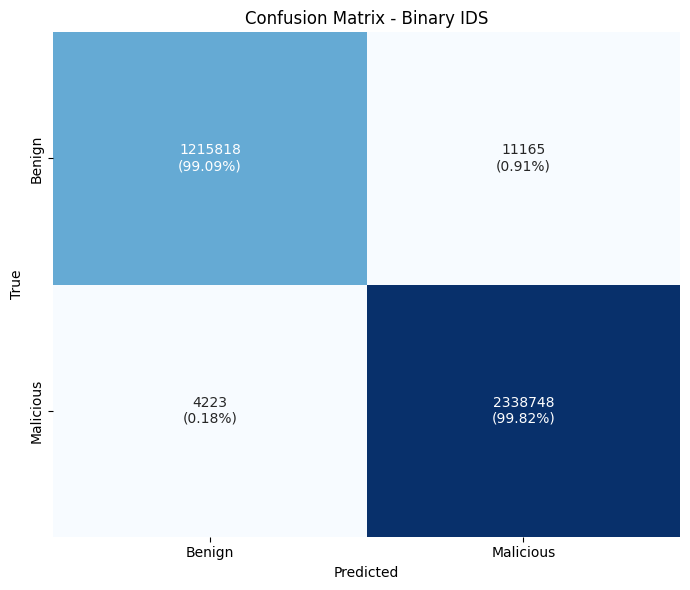

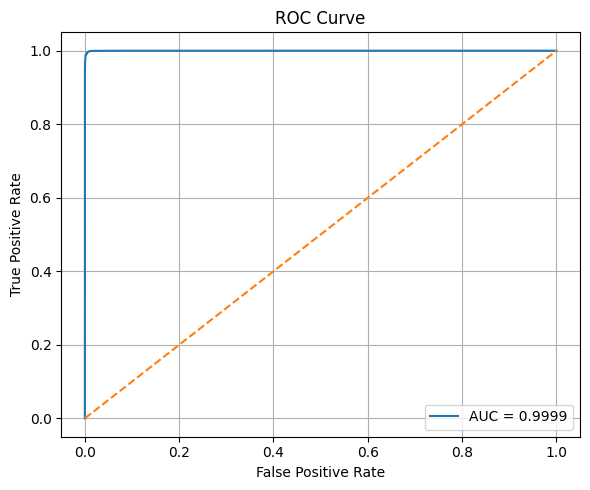

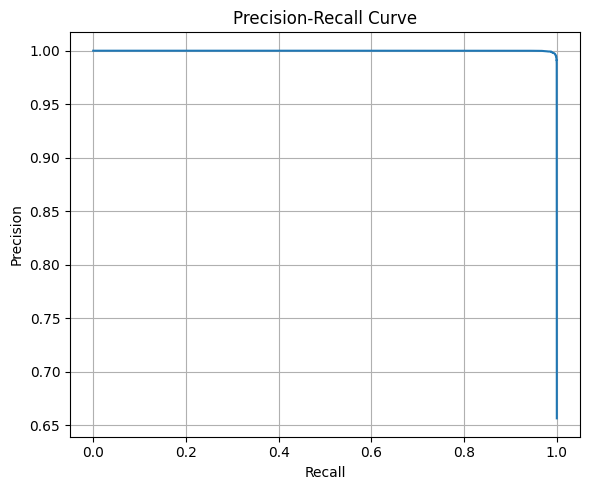

In [13]:
import torch
import torch.nn as nn
import polars as pl
import numpy as np
import glob
import matplotlib.pyplot as plt===== Epoch 7/8 =====
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

# ===============================
# DEVICE
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================
# LOAD MODEL
# ===============================
class ResidualMLP(nn.Module):
    def __init__(self, input_dim=37, num_classes=2):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, 1024)
        self.bn1 = nn.BatchNorm1d(1024)
        self.drop1 = nn.Dropout(0.15)

        self.fc2 = nn.Linear(1024, 1024)
        self.bn2 = nn.BatchNorm1d(1024)
        self.drop2 = nn.Dropout(0.15)

        self.fc3 = nn.Linear(1024, 512)
        self.bn3 = nn.BatchNorm1d(512)

        self.fc4 = nn.Linear(512, 256)
        self.bn4 = nn.BatchNorm1d(256)

        self.fc5 = nn.Linear(256, 128)
        self.bn5 = nn.BatchNorm1d(128)

        self.out = nn.Linear(128, 2)
        self.act = nn.GELU()

    def forward(self, x):
        x1 = self.act(self.bn1(self.fc1(x)))
        x1 = self.drop1(x1)

        x2 = self.act(self.bn2(self.fc2(x1)))
        x2 = x2 + x1
        x2 = self.drop2(x2)

        x3 = self.act(self.bn3(self.fc3(x2)))
        x4 = self.act(self.bn4(self.fc4(x3)))
        x5 = self.act(self.bn5(self.fc5(x4)))

        return self.out(x5)

model = ResidualMLP().to(device)

model.load_state_dict(
    torch.load("Trained/IDS-MLP-class_Binary-epoch7-F1_0.9967.pth",
               map_location=device,
               weights_only=True)
)

model.eval()
print("Model Loaded")

# ===============================
# LOAD TEST FILES
# ===============================
def get_chunk_number(path):
    return int(path.split("_")[-1].replace(".parquet", ""))

chunk_files = sorted(
    glob.glob("DataSet/class_Binary_chunks/*.parquet"),
    key=get_chunk_number
)

test_files = chunk_files[148:156]

# ===============================
# EVALUATE
# ===============================
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for file in test_files:
        df = pl.read_parquet(file)

        X = df.drop("Attack").to_numpy().astype(np.float32)
        y = df["Attack"].to_numpy().astype(np.int64)

        X_tensor = torch.from_numpy(X).to(device)

        outputs = model(X_tensor)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # malicious prob

        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(y)
        all_probs.extend(probs.cpu().numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_prob = np.array(all_probs)

# ===============================
# METRICS
# ===============================
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_prob)

print("\n================ METRICS ================")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))

# ===============================
# CONFUSION MATRIX
# ===============================
cm = confusion_matrix(y_true, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

labels = np.array([
    [f"{cm[i,j]}\n({cm_percent[i,j]*100:.2f}%)"
     for j in range(cm.shape[1])]
    for i in range(cm.shape[0])]
)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    xticklabels=["Benign", "Malicious"],
    yticklabels=["Benign", "Malicious"],
    cbar=False
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Binary IDS")
plt.tight_layout()
plt.show()

# ===============================
# ROC CURVE
# ===============================
fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ===============================
# PR CURVE
# ===============================
precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall_curve, precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.tight_layout()
plt.show()